# Iris Classification 

### Importing the libraries 

In [55]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn import tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree

### Importing Data sets 

In [56]:
df = pd.read_csv("../Data/Iris.csv")
df = df.drop('Id',axis=1)

### Splitting the dataset into training and testing as no cleaning is required

In [57]:
strat_train_set, strat_test_set = train_test_split(
    df, test_size= 0.2, stratify= df["Species"], random_state= 42
)
df = strat_train_set.copy()

### EDA

In [58]:
df.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
8,4.4,2.9,1.4,0.2,Iris-setosa
106,4.9,2.5,4.5,1.7,Iris-virginica
76,6.8,2.8,4.8,1.4,Iris-versicolor
9,4.9,3.1,1.5,0.1,Iris-setosa
89,5.5,2.5,4.0,1.3,Iris-versicolor


In [59]:
df.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,120.000000,120.000000,120.000000,120.000000
mean,5.841667,3.044167,3.770833,1.204167
std,0.840926,0.445669,1.767417,0.763825
min,4.300000,2.000000,1.100000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.750000,3.000000,4.250000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


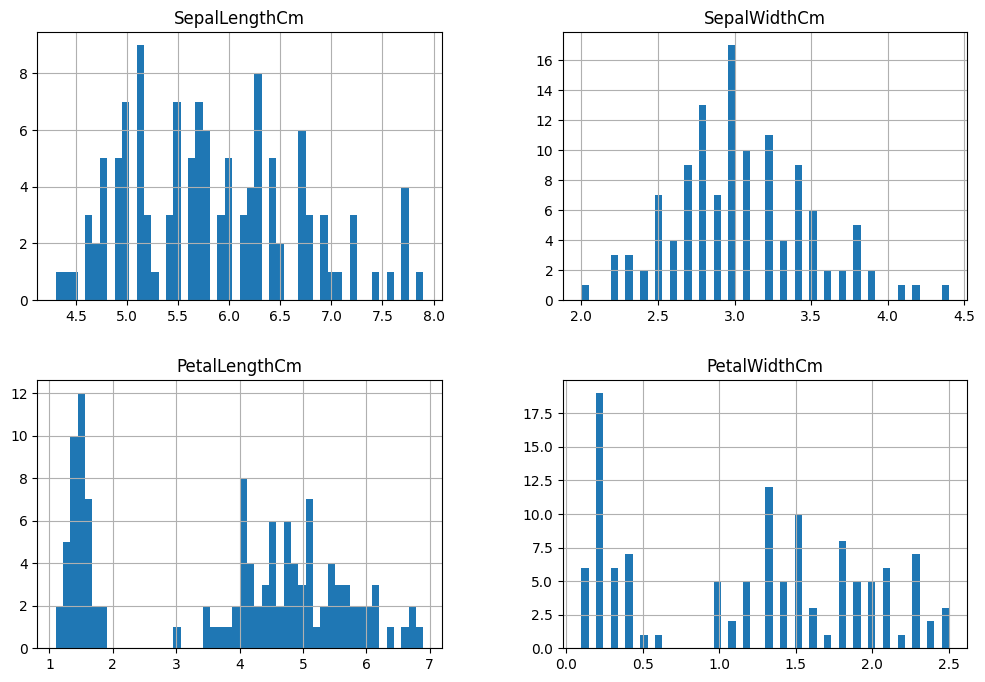

In [60]:
df.hist(bins= 50, figsize= (12,8))
plt.show()

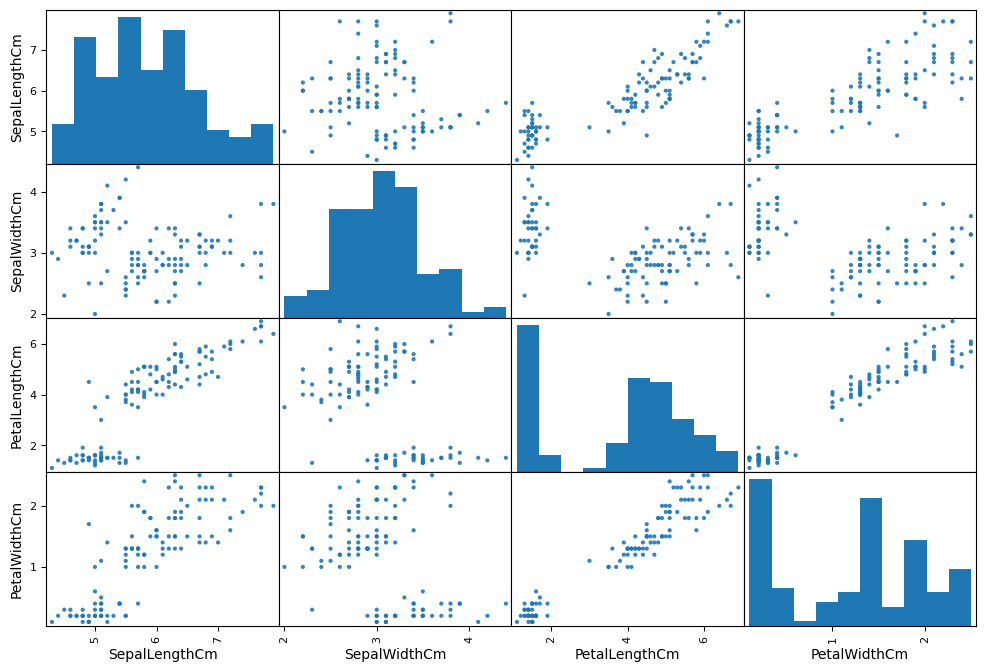

In [61]:
scatter_matrix(df,alpha= 0.9, figsize=(12,8), grid= True)
plt.show()

### Further Splitting Dataset

In [62]:
x_train = strat_train_set.drop('Species', axis= 1)
y_train = strat_train_set['Species'].copy()

x_test = strat_test_set.drop('Species', axis= 1)
y_test = strat_test_set['Species'].copy()

### Training Models

In [63]:
model = tree.DecisionTreeClassifier()
clf = model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [64]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [65]:
print("Train Accuracy:", model.score(x_train, y_train))
print("Test Accuracy:", model.score(x_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9666666666666667


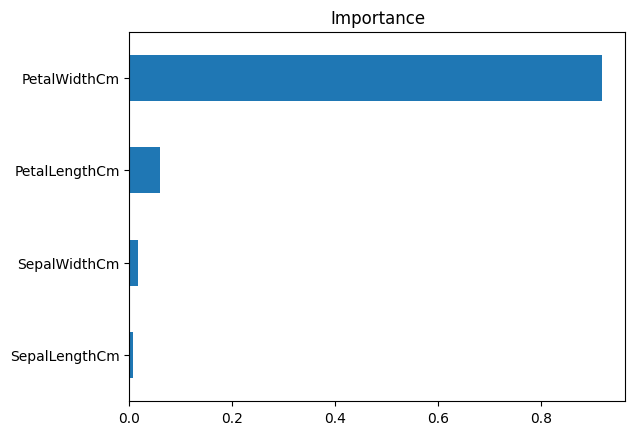

In [66]:
importance = pd.Series(model.feature_importances_, index= x_train.columns)
importance.sort_values().plot(kind= 'barh')
plt.title('Importance')
plt.show()

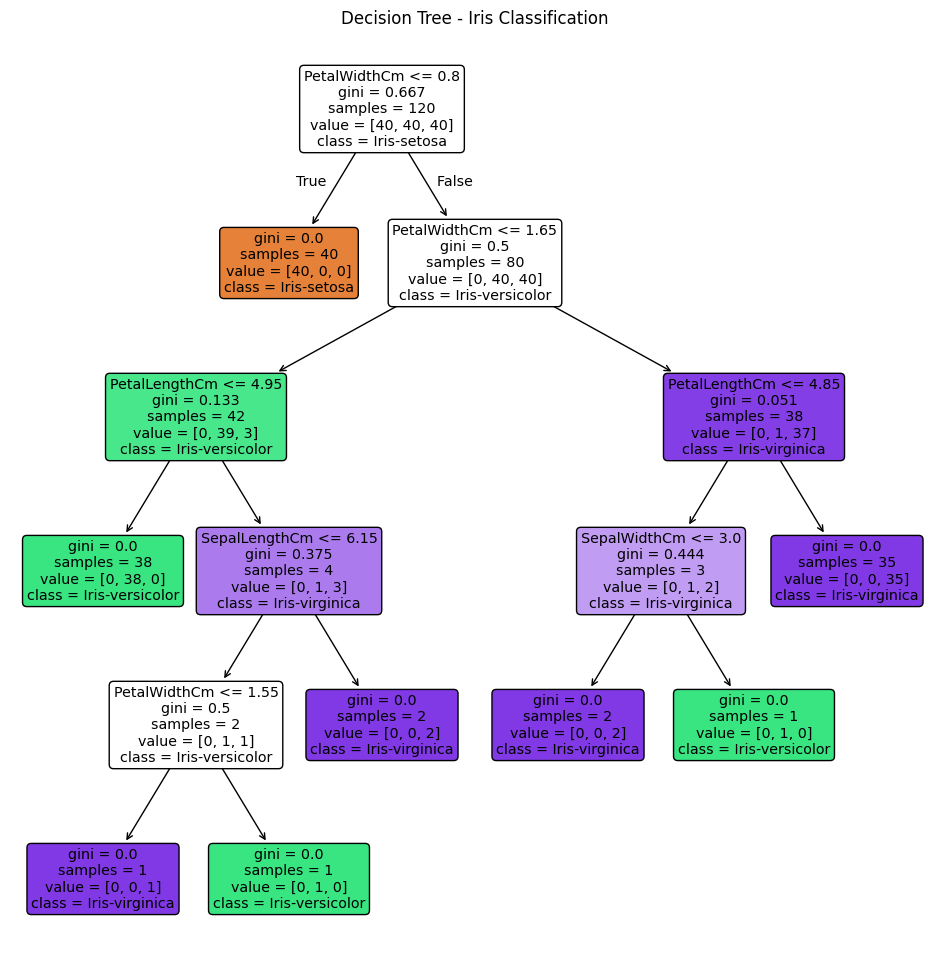

In [68]:
plt.figure(figsize=(12, 12))
plot_tree(
    model,
    feature_names=x_train.columns.tolist(),
    class_names=model.classes_.astype(str).tolist(),
    filled=True,
    rounded=True
)
plt.title("Decision Tree - Iris Classification")
plt.show()